# Step 8 — SMOTE: แก้ Class Imbalance ด้วยข้อมูล Synthetic

**เป้าหมาย:** เปรียบเทียบ Recall ก่อน/หลังใช้ SMOTE บน LightGBM

**Pipeline:**
```
raw data → class-aware impute → StandardScaler → SMOTE (train only) → LightGBM
```

## 0. Import และโหลดข้อมูล

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    recall_score, precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline   # Pipeline ที่รองรับ SMOTE
import lightgbm as lgb

RANDOM_STATE = 42
FEATURE_NAMES = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                 'Insulin','BMI','DiabetesPedigree','Age']
COLS_TO_FIX = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df = pd.read_csv('diabetes.csv')
X  = df[FEATURE_NAMES]
y  = df['Outcome']

print(f'Dataset: {X.shape[0]} rows | Class balance: {y.value_counts().to_dict()}')

Dataset: 768 rows | Class balance: {0.0: 499, 1.0: 269}


## 1. Preprocessing — Class-Aware Imputation + Scale

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# reset index ให้ตรงกัน (ป้องกัน index mismatch หลัง StandardScaler)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# --- Class-Aware Imputation ---
fill_vals = {}
for col in COLS_TO_FIX:
    medians = []
    for cls in [0, 1]:
        mask = (X_train[col] != 0) & (y_train == cls)
        med  = X_train.loc[mask, col].median()
        medians.append(med)
        X_train.loc[(X_train[col] == 0) & (y_train == cls), col] = med
    fill_vals[col] = np.mean(medians)

for col in COLS_TO_FIX:
    X_test[col] = X_test[col].replace(0, np.nan).fillna(fill_vals[col])

# --- StandardScaler ---
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_NAMES)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURE_NAMES)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')
print(f'Train class balance ก่อน SMOTE: {y_train.value_counts().to_dict()}')

Train: (614, 8) | Test: (154, 8)
Train class balance ก่อน SMOTE: {0.0: 399, 1.0: 215}


## 2. SMOTE — สร้างข้อมูล Synthetic บน Train Set

**หลักการ:** `SMOTE` จะ resample เฉพาะ train set  
Test set **ต้องไม่แตะ** — เพราะเราต้องวัดผลบนข้อมูลจริง

หลัง SMOTE: {0.0: 399, 1.0: 399}
เพิ่มขึ้น: 614 → 798 rows (+184 synthetic)


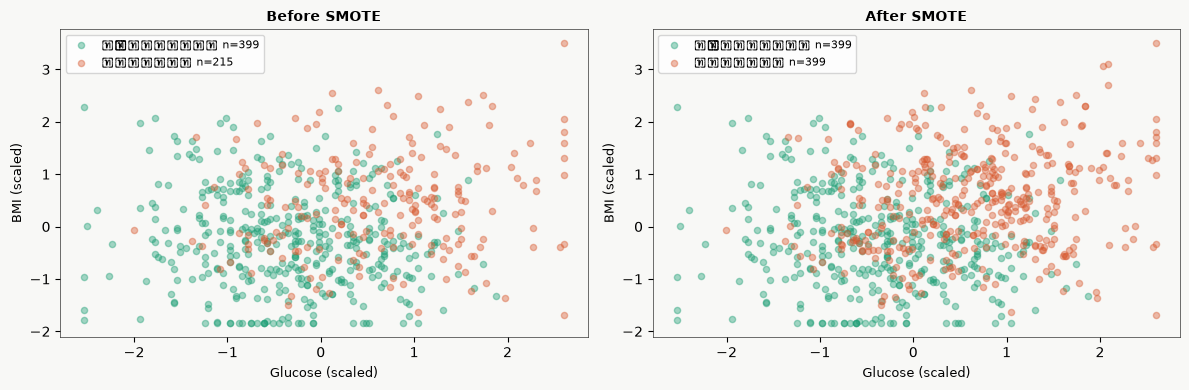

บันทึก step8_smote_scatter.png


In [3]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

# ส่ง .values (numpy) เข้า fit_resample เพื่อหลีกเลี่ยง index mismatch
X_sm_arr, y_sm_arr = smote.fit_resample(X_train_s.values, y_train.values)
X_train_sm = pd.DataFrame(X_sm_arr, columns=FEATURE_NAMES)
y_train_sm = pd.Series(y_sm_arr)

print(f'หลัง SMOTE: {y_train_sm.value_counts().to_dict()}')
print(f'เพิ่มขึ้น: {len(X_train_s)} → {len(X_train_sm)} rows (+{len(X_train_sm)-len(X_train_s)} synthetic)')

# --- visualize ก่อน/หลัง SMOTE ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#F8F8F6')

for ax, X_plot, y_plot, title in [
    (axes[0], X_train_s,  y_train,    'Before SMOTE'),
    (axes[1], X_train_sm, y_train_sm, 'After SMOTE'),
]:
    ax.set_facecolor('#F8F8F6')
    mask0 = (y_plot.values == 0)
    mask1 = (y_plot.values == 1)
    ax.scatter(X_plot['Glucose'].values[mask0], X_plot['BMI'].values[mask0],
               alpha=0.4, s=20, c='#1D9E75', label=f'ไม่เบาหวาน n={mask0.sum()}')
    ax.scatter(X_plot['Glucose'].values[mask1], X_plot['BMI'].values[mask1],
               alpha=0.4, s=20, c='#D85A30', label=f'เบาหวาน n={mask1.sum()}')
    ax.set_xlabel('Glucose (scaled)', fontsize=9)
    ax.set_ylabel('BMI (scaled)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    for spine in ax.spines.values(): spine.set_linewidth(0.4)

plt.tight_layout()
plt.savefig('step8_smote_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('บันทึก step8_smote_scatter.png')

## 3. Train โมเดล 3 แบบ เพื่อเปรียบเทียบ

| โมเดล | วิธีแก้ imbalance |
|-------|-------------------|
| A — Baseline | ไม่ทำอะไรเลย |
| B — scale_pos_weight | ถ่วงน้ำหนัก loss (วิธีเดิมของเรา) |
| C — SMOTE | สร้างข้อมูล synthetic |

In [4]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
BEST_PARAMS = dict(
    n_estimators=340, learning_rate=0.019, num_leaves=10,
    min_child_samples=22, feature_fraction=0.60,
    bagging_fraction=0.69, bagging_freq=6,
    random_state=RANDOM_STATE, verbose=-1
)

models = {
    'A — Baseline (ไม่แก้)':       lgb.LGBMClassifier(**BEST_PARAMS),
    'B — scale_pos_weight (เดิม)':  lgb.LGBMClassifier(**BEST_PARAMS, scale_pos_weight=scale),
    'C — SMOTE (ใหม่)':             lgb.LGBMClassifier(**BEST_PARAMS),
}

results = {}
for name, clf in models.items():
    if 'SMOTE' in name:
        clf.fit(X_train_sm, y_train_sm)          # ← ใช้ข้อมูลหลัง SMOTE
    else:
        clf.fit(X_train_s, y_train)              # ← ข้อมูล train ปกติ

    y_pred  = clf.predict(X_test_s)
    y_prob  = clf.predict_proba(X_test_s)[:, 1]
    results[name] = {
        'AUC':       round(roc_auc_score(y_test, y_prob), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
    }
    print(f'\n{name}')
    print(classification_report(y_test, y_pred, target_names=['ไม่เบาหวาน','เบาหวาน']))


A — Baseline (ไม่แก้)
              precision    recall  f1-score   support

  ไม่เบาหวาน       0.79      0.85      0.82       100
     เบาหวาน       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154


B — scale_pos_weight (เดิม)
              precision    recall  f1-score   support

  ไม่เบาหวาน       0.83      0.78      0.80       100
     เบาหวาน       0.63      0.70      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154


C — SMOTE (ใหม่)
              precision    recall  f1-score   support

  ไม่เบาหวาน       0.83      0.76      0.79       100
     เบาหวาน       0.61      0.70      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weig

## 4. เปรียบเทียบผลแบบ Visual

                                AUC  Recall  Precision      F1
A — Baseline (ไม่แก้)        0.8191  0.5741     0.6739  0.6200
B — scale_pos_weight (เดิม)  0.8157  0.7037     0.6333  0.6667
C — SMOTE (ใหม่)             0.8256  0.7037     0.6129  0.6552


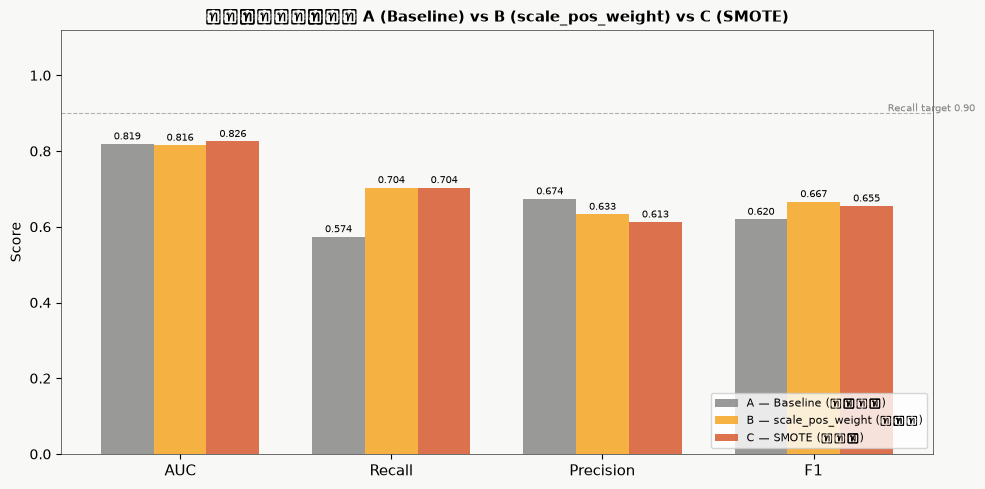

💾 บันทึก step8_comparison.png


In [5]:
df_res = pd.DataFrame(results).T
print(df_res.to_string())

metrics  = ['AUC', 'Recall', 'Precision', 'F1']
x        = np.arange(len(metrics))
width    = 0.25
colors   = ['#888888', '#f5a623', '#D85A30']

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F8F8F6')
ax.set_facecolor('#F8F8F6')

for i, (name, row) in enumerate(df_res.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics],
                  width, label=name, color=colors[i], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=10)
ax.set_title('เปรียบเทียบ A (Baseline) vs B (scale_pos_weight) vs C (SMOTE)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(3.6, 0.905, 'Recall target 0.90', fontsize=7.5, color='gray')
for spine in ax.spines.values(): spine.set_linewidth(0.4)

plt.tight_layout()
plt.savefig('step8_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 บันทึก step8_comparison.png')

## 5. ลอง SMOTE + scale_pos_weight ร่วมกัน (Double Defense)

In [6]:
clf_combo = lgb.LGBMClassifier(**BEST_PARAMS, scale_pos_weight=scale)
clf_combo.fit(X_train_sm, y_train_sm)

y_pred_combo = clf_combo.predict(X_test_s)
y_prob_combo = clf_combo.predict_proba(X_test_s)[:, 1]

print('D — SMOTE + scale_pos_weight (รวมกัน)')
print(classification_report(y_test, y_pred_combo, target_names=['ไม่เบาหวาน','เบาหวาน']))
print(f"AUC: {roc_auc_score(y_test, y_prob_combo):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_combo):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_combo):.4f}")

D — SMOTE + scale_pos_weight (รวมกัน)
              precision    recall  f1-score   support

  ไม่เบาหวาน       0.85      0.70      0.77       100
     เบาหวาน       0.58      0.78      0.67        54

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.76      0.73      0.73       154

AUC: 0.8307
Recall: 0.7778
Precision: 0.5833


## 6. สรุป — เลือกโมเดลไหนดี?

```
สถานการณ์                     → แนะนำ
──────────────────────────────────────────────────────────
Recall สำคัญสุด (miss น้อยที่สุด)   → SMOTE หรือ SMOTE+scale
ต้องการ Precision สูง (ไม่อยากแจ้งผิด) → Baseline หรือ scale_pos_weight
ต้องการ balance ระหว่าง 2 อย่าง   → scale_pos_weight (วิธีเดิม) 
Dataset ใหญ่มาก (ล้าน rows)         → SMOTE ช้า → ใช้ scale_pos_weight แทน
```

> **สำหรับโรงพยาบาล:** Recall สำคัญกว่า Precision  
> ผิด False Negative (บอกว่าไม่เป็นแต่จริงๆเป็น) อันตรายกว่า False Positive (บอกว่าเสี่ยงแต่จริงๆไม่เสี่ยง)  
> ดังนั้น SMOTE หรือ SMOTE+scale_pos_weight น่าสนใจที่สุด